In [2]:
a1 = 0.93
a2 = 0.02515
b0 = 1.786
b1 = 1
lam1=-0.90855044 
lam2=-0.02768793

In [3]:
import numpy as np
y_hat = np.load("y_hat.npy")
x_hat = np.load("x_hat.npy")

print(y_hat)

Y=y_hat.copy()
X=x_hat.copy()
N=len(Y)
print(len(Y),len(X))

[ 0.          0.65922888  0.12984167 ... -0.66044293 -0.51274423
 -0.38994694]
52608 52608


In [4]:
comp=np.zeros((N,2))
coef=np.array([[lam2*(b0+lam1),-(b0+lam1)],[-lam1*(b0+lam2),b0+lam2]])

for i in range(N):
    comp[i]=(1/(lam2-lam1))*coef@X[i]


In [5]:
dL=np.zeros(N-1)
alpha2=(b0+lam2)/(lam2-lam1)
for i in range(N-1):
    A=(1/2)*(comp[i+1,1]+comp[i,1])
    dL[i]=(1/alpha2)*((comp[i+1,1]-comp[i,1])-lam2*A)

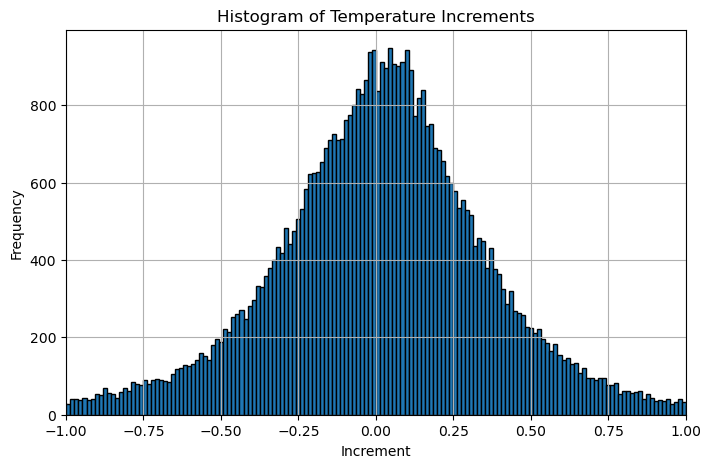

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(dL, bins=800, edgecolor="black")
plt.xlim(-1,1)
plt.title("Histogram of Temperature Increments")
plt.xlabel("Increment")
plt.ylabel("Frequency")
plt.grid(alpha=1)
plt.show()

In [7]:
from pathlib import Path

DATA_DIR = Path("../data")
import pandas as pd

dLdf = pd.DataFrame(dL, columns=["dL"])
temp_inc_path = DATA_DIR / "increments" / "temp_inc.csv"
dLdf.to_csv(temp_inc_path, mode="a", header=False, index=False)